<a href="https://colab.research.google.com/github/PabloDuranL/Miprogresionypraticas/blob/main/RegresionMLEMAPDiabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCMC Metropolis Hosting para regresion lineal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
diabetes=load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target
x = diabetes.data
y = diabetes.target

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=123)

In [ ]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [ ]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


<Axes: >

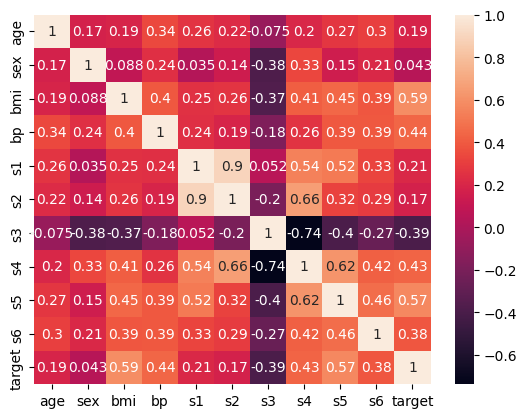

In [ ]:
matxcorr=df.corr()
sns.heatmap(matxcorr, annot=True)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

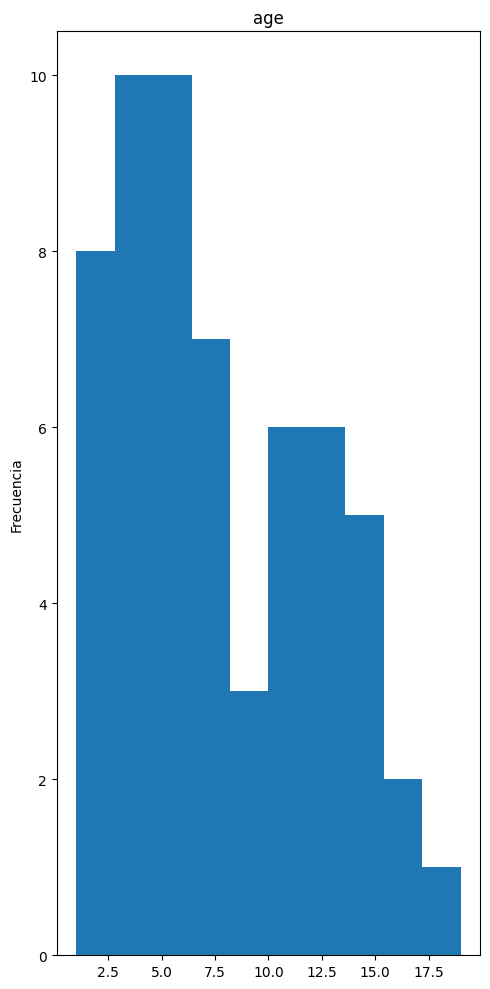

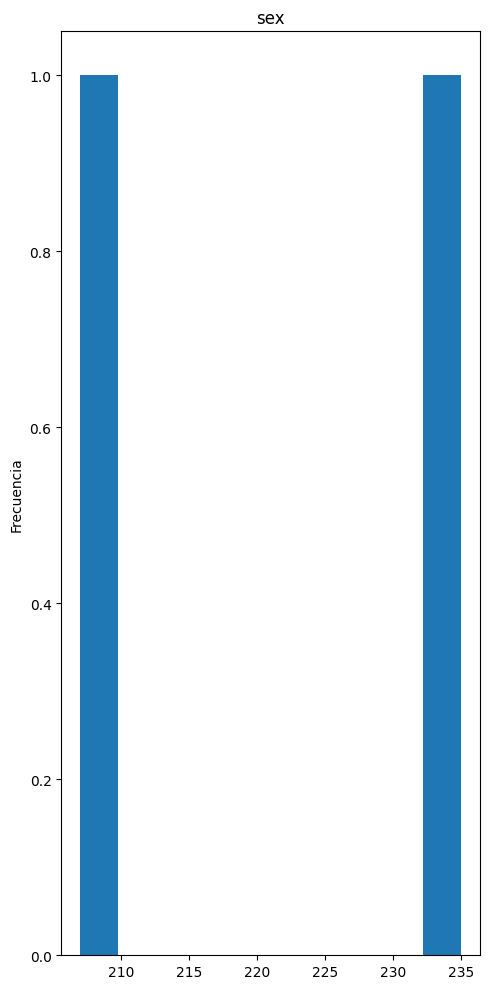

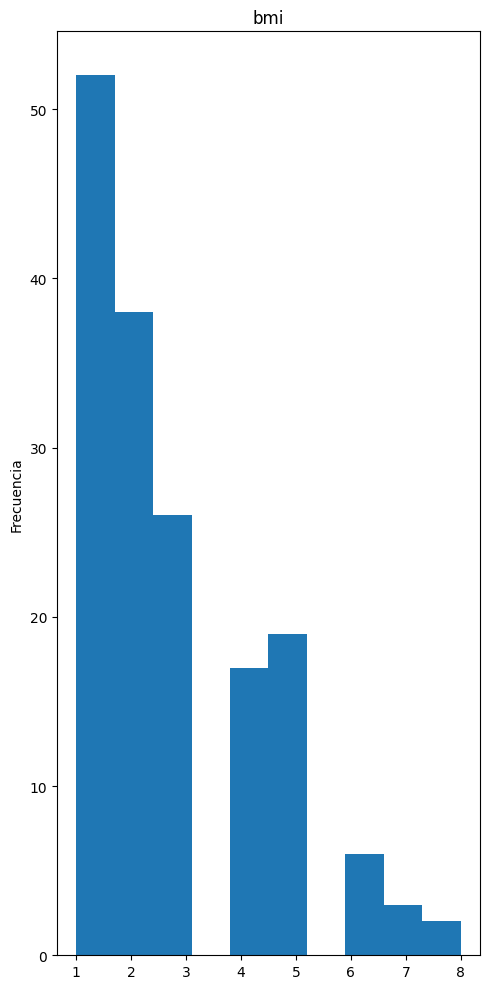

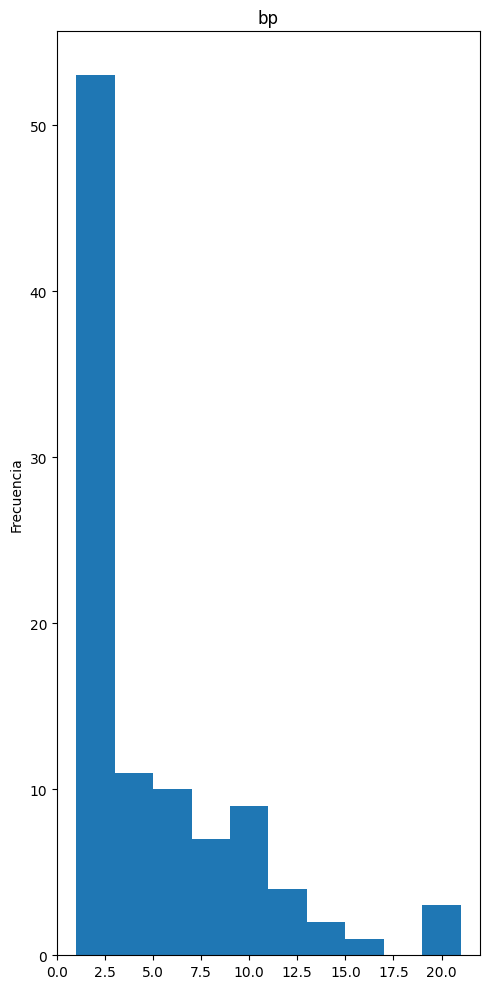

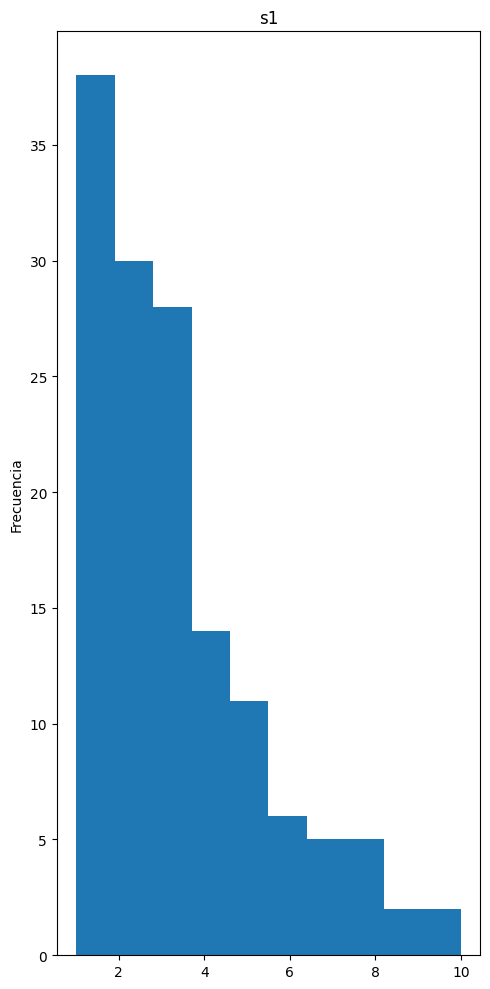

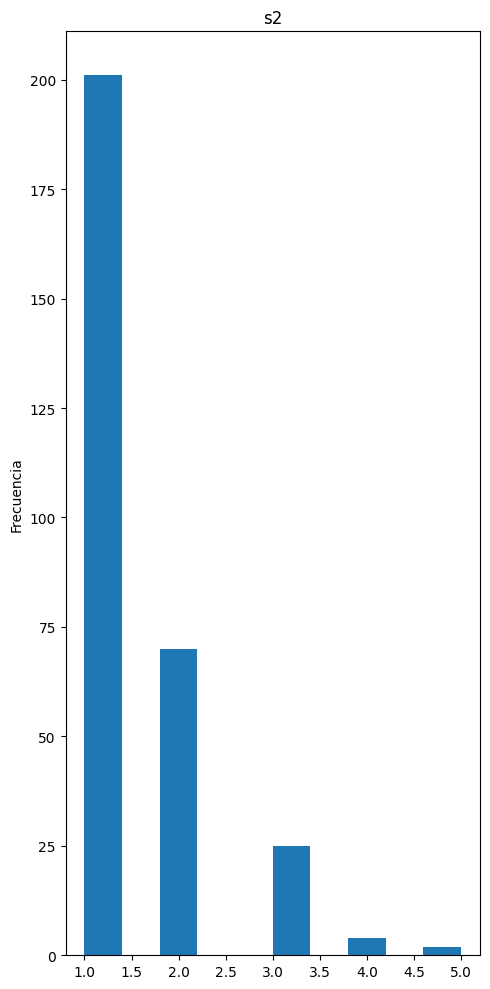

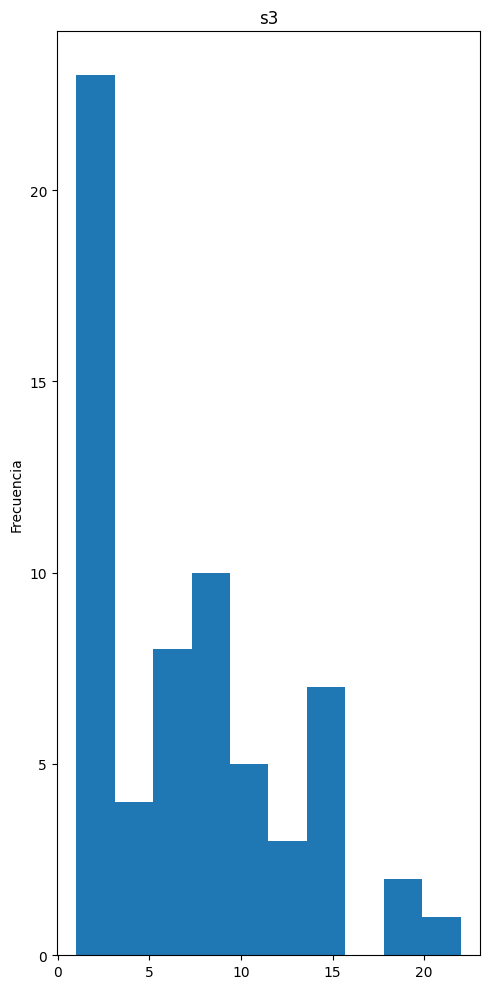

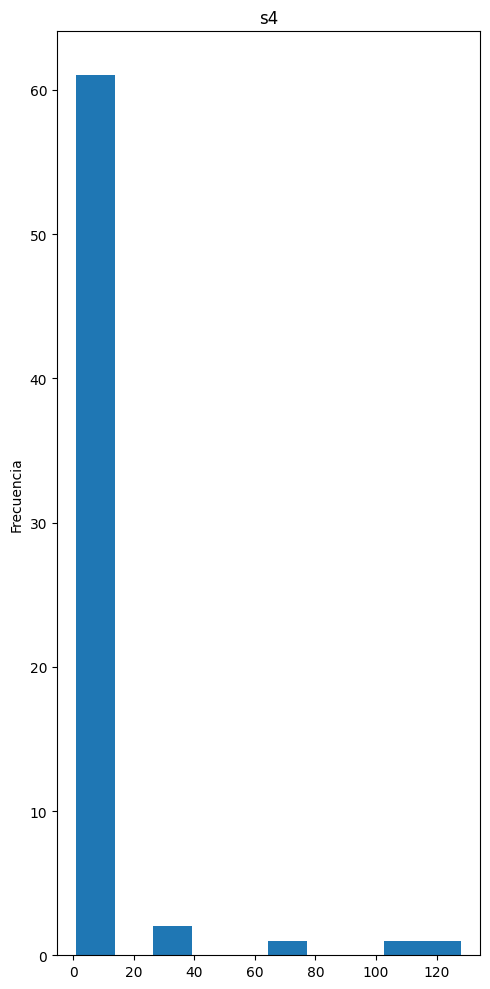

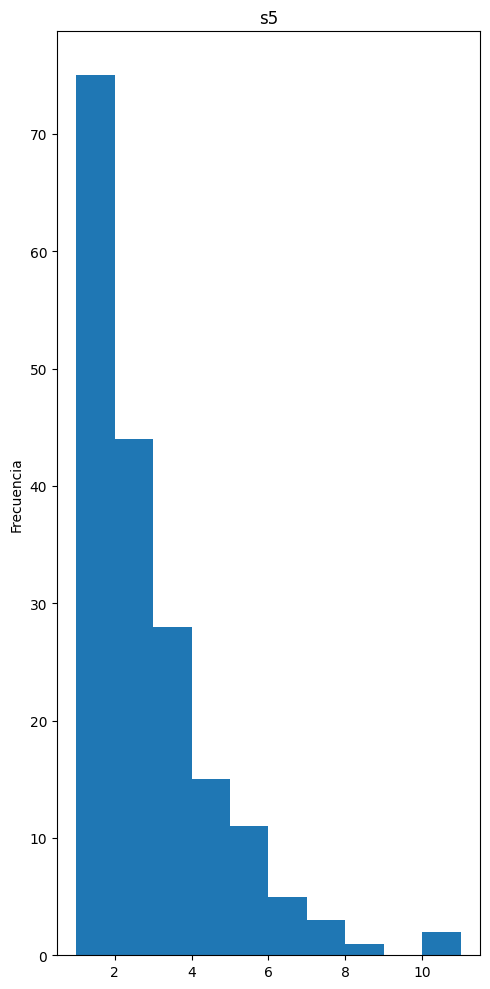

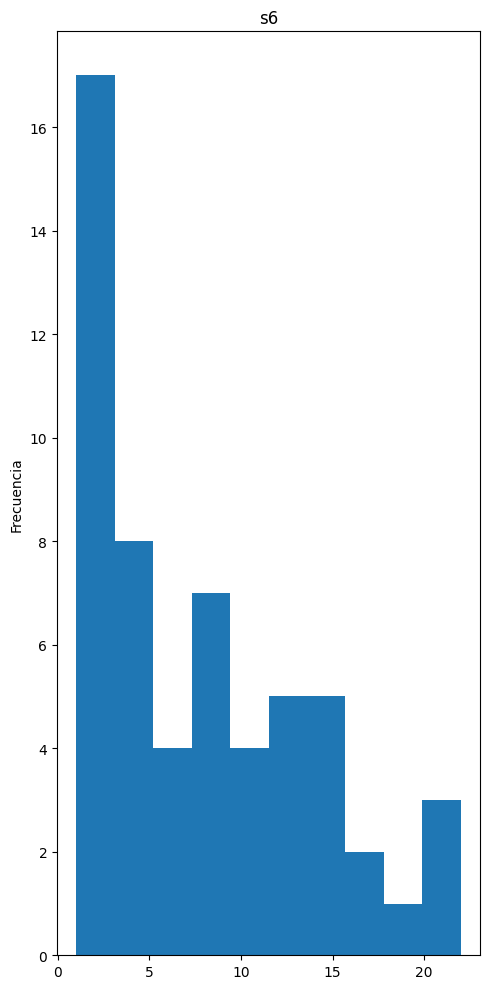

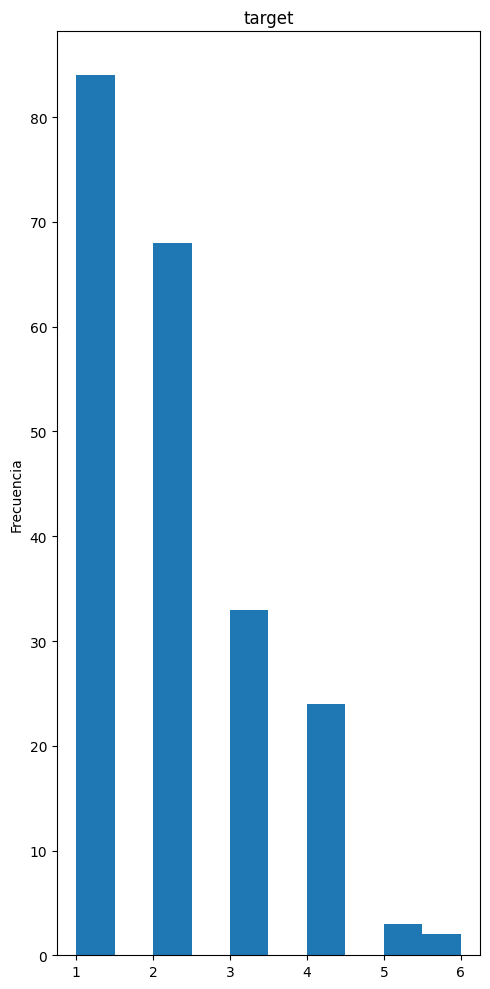

In [ ]:
for i in df.columns:
  plt.figure(figsize=(5,10))
  df.value_counts(i).plot(kind="hist")
  plt.title(i)
  plt.ylabel("Frecuencia")
  plt.tight_layout()
  plt.show()


In [ ]:
unos=pd.DataFrame({"unos":np.ones(x_train.shape[0])})
phi_train=pd.concat([unos, pd.DataFrame(x_train)], axis=1)
unos=pd.DataFrame({"unos":np.ones(x_test.shape[0])})
phi_test=pd.concat([unos, pd.DataFrame(x_test)], axis=1)

In [ ]:
#Matriz Pesos
w=np.linalg.inv(phi_train.T.dot(phi_train)).dot(phi_train.T.dot(y_train))

In [ ]:
w

array([ 152.04835226,   -6.18504945, -225.23239417,  505.20147591,
        295.61096358, -826.05108427,  466.91042831,  130.74554142,
        252.95462152,  691.08257004,  111.20752686])

In [ ]:
#Prediccion
y_pred=phi_test.dot(w)
SSE=np.sum((y_pred-y_test)**2)
y_mean=np.mean(y_test)
SST=np.sum((y_test-y_mean)**2)
R_square=1-SSE/SST
R_square

np.float64(0.567589572579321)

In [ ]:
y_pred.shape

(89,)

In [ ]:
modelo=LinearRegression()
modelo.fit(x_train,y_train)
r=modelo.score(x_test,y_test)
comp=pd.DataFrame({'Coeficientes Regresion':w, 'Coeficientes de ScikitLearn': np.concatenate([np.array([modelo.intercept_]),modelo.coef_])})
comp

,Coeficientes Regresion,Coeficientes de ScikitLearn
0,152.048352,152.048352
1,-6.185049,-6.185049
2,-225.232394,-225.232394
3,505.201476,505.201476
4,295.610964,295.610964
5,-826.051084,-826.051084
6,466.910428,466.910428
7,130.745541,130.745541
8,252.954622,252.954622
9,691.082570,691.082570


In [ ]:
np.array([modelo.score(x_test,y_test),R_square])

array([0.56758957, 0.56758957])

## Inferencia Bayesiana sobre el prior w a partir de una multivariada Normal(0,alpha I) donde I es la matriz identidad (MAP)

In [ ]:
alpha = 1.
beta = 1.

hist_alpha = []
hist_beta = []
hist_gamma = []

I = np.eye(phi_train.shape[1])

N = len(y_train)

eigvals = np.linalg.eigvalsh(
    phi_train.T.dot(phi_train)
)

for i in range(100):

    SN = np.linalg.inv(
        alpha*I +
        beta*phi_train.T.dot(phi_train)
    )

    mn = beta*SN.dot(phi_train.T.dot(y_train))

    lambda_i = beta*eigvals

    gamma = np.sum(
        lambda_i/(alpha+lambda_i)
    )

    alpha_new = gamma/(mn@mn)

    res = y_train - phi_train.dot(mn)

    beta_new = (N-gamma)/(res@res)

    hist_alpha.append(alpha)
    hist_beta.append(beta)
    hist_gamma.append(gamma)

    if (
    np.abs(alpha-alpha_new)/(alpha+1e-12) < 1e-6
    and
    np.abs(beta-beta_new)/(beta+1e-12) < 1e-6):
     break

    alpha = alpha_new
    beta = beta_new

print(alpha)
print(beta)

1.3968198204406964e-05
0.0003323246704317613


In [ ]:

I=np.eye(phi_train.shape[1])
SN=np.linalg.inv(alpha*I+beta*(phi_train.T.dot(phi_train)))
mn=beta*SN.dot(phi_train.T.dot(y_train))
mn.shape

(11,)

In [ ]:
y_predmap=mn.dot(phi_test.T)
y_predmap.shape

(89,)

In [ ]:
print("RMSE MAP")
errormap=np.sqrt(mean_squared_error(y_test,y_predmap))
print(errormap)


RMSE MAP
52.66240331417656


In [ ]:
print("RMSE MLE")
errormle=np.sqrt(mean_squared_error(y_test,y_pred))
print(errormle)

RMSE MLE
52.19442575216967


In [ ]:
vartot=(1/beta)*(np.eye(y_test.shape[0]))+phi_test.dot(SN.dot(phi_test.T))
var=np.diag(vartot)
std=np.sqrt(var)

# **predicciones con intervalo de credibilidad al 95%** con Z0.95=1.96

In [ ]:
lim_sup=y_predmap+1.96*std
lim_inf=y_predmap-1.96*std


In [ ]:
intervalos=pd.DataFrame({'Y REAL':y_test,'LIMITE INFERIOR':lim_inf, 'RESPUESTA MEDIA':y_predmap, 'LIMITE SUPERIOR':lim_sup})
intervalos

,Y REAL,LIMITE INFERIOR,RESPUESTA MEDIA,LIMITE SUPERIOR
0,185.0,51.138130,159.269359,267.400587
1,150.0,43.541488,152.085620,260.629752
2,246.0,115.738085,224.291389,332.844693
3,184.0,52.458536,160.865281,269.272027
4,110.0,47.985730,156.682269,265.378809
...,...,...,...,...
84,258.0,175.805432,285.189923,394.574414
85,235.0,57.607880,166.230130,274.852379
86,173.0,86.678841,195.063056,303.447272
87,59.0,-37.011109,71.405014,179.821137


In [ ]:
w_muestras=np.random.multivariate_normal(mean=mn, cov=SN, size=50000)
pred_w= w_muestras.dot(phi_test.T)
pred_w


array([[155.86475525, 169.89602063, 227.80926353, ..., 203.22734561,
         65.92156029, 146.0151341 ],
       [164.32321578, 161.57140736, 231.52557354, ..., 204.1687162 ,
         80.93949704, 152.01485159],
       [155.62455734, 164.43505753, 219.83438874, ..., 204.74297479,
         78.29307831, 121.02502065],
       ...,
       [152.87343121, 157.17389022, 215.17375168, ..., 184.48323743,
         68.40937991, 134.53477314],
       [161.7493445 , 146.78302698, 230.28111711, ..., 205.28601361,
         84.43862683, 140.94774918],
       [163.80842428, 167.36392894, 229.65217747, ..., 202.06661511,
         76.19531015, 143.66953581]])

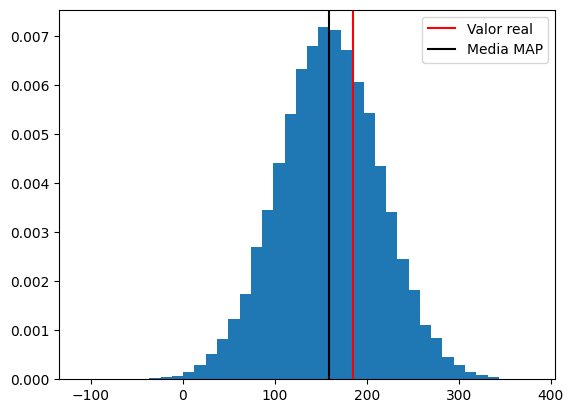

In [ ]:
pred_1 = pred_w[:,0] + np.random.normal(
    0,
    np.sqrt(1/beta),
    size=pred_w.shape[0]
)

plt.hist(pred_1,
         bins=40,
         density=True)

plt.axvline(
    y_test[0],
    color="red",
    label="Valor real"
)

plt.axvline(
    y_predmap[0],
    color="black",
    label="Media MAP"
)

plt.legend()
plt.show()

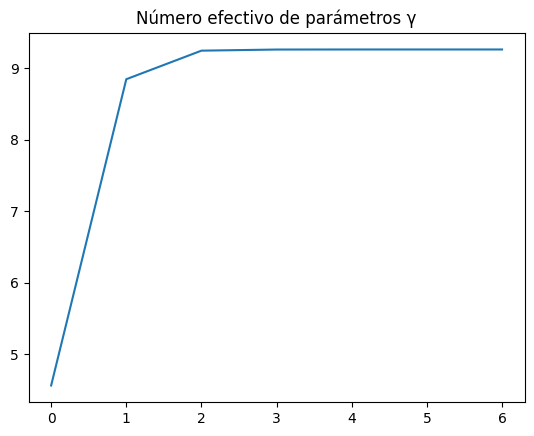

In [ ]:
plt.plot(hist_gamma)
plt.title("Número efectivo de parámetros γ")
plt.show()

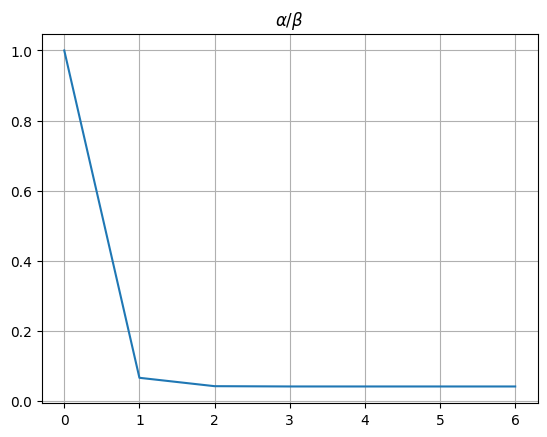

In [ ]:
hist_lambda = np.array(hist_alpha)/np.array(hist_beta)

plt.plot(hist_lambda)
plt.title(r"$\alpha/\beta$")
plt.grid(True)
plt.show()

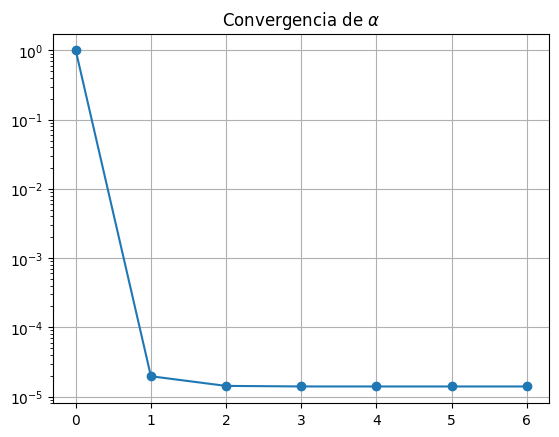

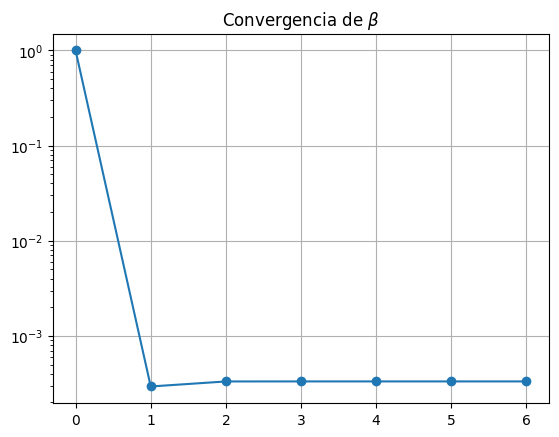

In [ ]:
plt.semilogy(hist_alpha, marker="o")
plt.title(r"Convergencia de $\alpha$")
plt.grid(True)
plt.show()

plt.semilogy(hist_beta, marker="o")
plt.title(r"Convergencia de $\beta$")
plt.grid(True)
plt.show()